In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [14]:
df = pd.read_csv('../data/Mall_Customers.csv')

In [15]:
#  using sklearn to OneHotEncode
from sklearn.preprocessing import OneHotEncoder

# OneHotEncoder
ohe = OneHotEncoder(drop='first', sparse_output=False)
gender_encoded = ohe.fit_transform(df[['Gender']])

# Create DataFrame with encoded columns
feature_names = ohe.get_feature_names_out(['Gender'])
encoded_df = pd.DataFrame(gender_encoded, columns=feature_names, index=df.index)

# Drop original categorical columns and concatenate
df = df.drop('Gender', axis=1)
df = pd.concat([df, encoded_df], axis=1)

In [16]:
df =df.drop(columns=["CustomerID"])

In [17]:
X = df

In [18]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

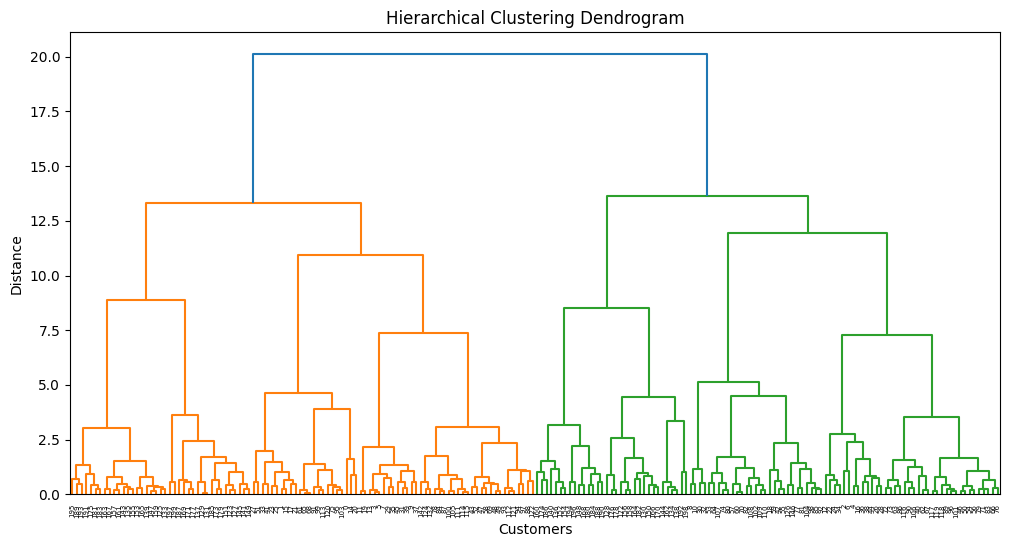

In [19]:
# Create Dendrogram
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage

plt.figure(figsize=(12, 6))

Z = linkage(X_scaled, method='ward')

dendrogram(Z)

plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Customers')
plt.ylabel('Distance')
plt.show()

In [23]:
# Fit Hierarchical Clustering

from sklearn.cluster import AgglomerativeClustering

hc = AgglomerativeClustering(
    n_clusters=2,
    metric='euclidean',
    linkage='ward'
)

df['hc_cluster'] = hc.fit_predict(X_scaled)

In [24]:
# Check Cluster Sizes

print(df['hc_cluster'].value_counts().sort_index())

hc_cluster
0    100
1    100
Name: count, dtype: int64


In [ ]:
# Profile the Clusters

In [25]:
df.groupby('hc_cluster').agg({
    'Age':'mean',
    'Annual Income (k$)':'mean',
    'Spending Score (1-100)':'mean',
    'Gender_Male':'mean'
}).round(2)

,Age,Annual Income (k$),Spending Score (1-100),Gender_Male
hc_cluster,,,,
0,49.0,60.67,32.4,0.47
1,28.7,60.45,68.0,0.41


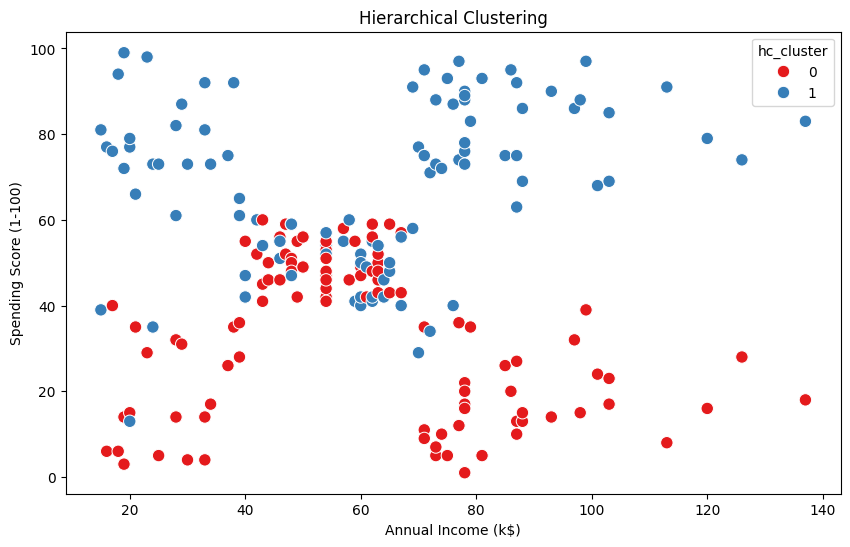

In [26]:
# Visualize using Spending and Income

import seaborn as sns

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='hc_cluster',
    palette='Set1',
    s=80
)

plt.title('Hierarchical Clustering')
plt.show()

In [27]:
from sklearn.metrics import silhouette_score

score = silhouette_score(X_scaled, df['hc_cluster'])

print(f"Silhouette Score: {score:.3f}")

Silhouette Score: 0.242
